<a href="https://colab.research.google.com/github/drawcodeboy/Cat_n_Dog_Classification/blob/main/cat_n_dog_data_preprocessing_ver2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from PIL import Image

In [8]:
train_set = np.load('/content/drive/MyDrive/cat_n_dog/data_numpy/train_set.npy', allow_pickle=True)
test_set = np.load('/content/drive/MyDrive/cat_n_dog/data_numpy/test_set.npy', allow_pickle=True)

train_target = np.load('/content/drive/MyDrive/cat_n_dog/data_numpy/train_target.npy', allow_pickle=True)
test_target = np.load('/content/drive/MyDrive/cat_n_dog/data_numpy/test_target.npy', allow_pickle=True)

allow_pickle error
https://stackoverflow.com/questions/55890813/how-to-fix-object-arrays-cannot-be-loaded-when-allow-pickle-false-for-imdb-loa

In [9]:
print(train_set.shape, train_target.shape, test_set.shape, test_target.shape)

(8005,) (8005,) (2023,) (2023,)


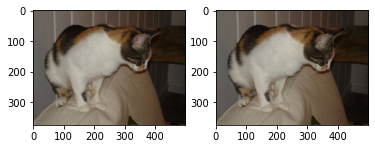

In [10]:
fig, axs = plt.subplots(1, 2)

axs[0].imshow(train_set[0])
axs[1].imshow(train_set[0] / 255.0)

plt.show()

In [11]:
# image_preprocessing: center cropping
def crop_center(img):
    y, x, z = img.shape
    crop_size = min(y, x)

    start_x = x // 2 - (crop_size // 2)
    start_y = y // 2 - (crop_size // 2)
    img = img[start_y:start_y + crop_size, start_x:start_x + crop_size]
    img_256x256 = cv2.resize(img, (256, 256))
    return img_256x256

reference: https://stackoverflow.com/questions/39382412/crop-center-portion-of-a-numpy-image

In [12]:
def minmax_scaler(img):
    return img / 255.0

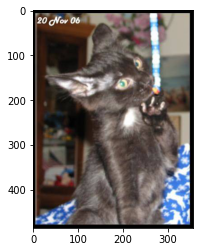

In [13]:
plt.imshow(train_set[2])

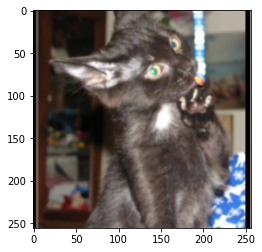

In [14]:
plt.imshow(crop_center(train_set[2]))

In [ ]:
# Numpy를 가져오는 과정에서 RAM을 다 사용해서
# 전처리하기에 런타임이 다운 된다.

train_scaled = []

for img in train_set:
    img_crop = crop_center(img)
    img_scaled = minmax_scaler(img_crop)
    train_scaled.append(img_scaled)

train_scaled = np.array(train_scaled)